## Part 1: Install and Configure Elasticsearch

In [ ]:
ES_VERSION = "8.11.3"

import os

primary_url = f"https://artifacts.elastic.co/downloads/elasticsearch/elasticsearch-{ES_VERSION}-linux-x86_64.tar.gz"

!wget -q "{primary_url}" -O elasticsearch.tar.gz

size = os.path.getsize("elasticsearch.tar.gz") if os.path.exists("elasticsearch.tar.gz") else 0
print(f"Downloaded elasticsearch.tar.gz: {size} bytes")

assert size > 10_000_000, (
    "Elasticsearch download failed or is too small. Check your Colab internet "
    "connection, or verify the current version/URL at "
    "https://www.elastic.co/downloads/elasticsearch and update ES_VERSION above."
)

!tar -xzf elasticsearch.tar.gz
!mv elasticsearch-{ES_VERSION} elasticsearch
!chown -R daemon:daemon elasticsearch
print("Elasticsearch extracted successfully.")

Downloaded elasticsearch.tar.gz: 630500349 bytes
Elasticsearch extracted successfully.


In [ ]:
# Disable security features for this local dev setup, and configure single-node mode.

config_path = "elasticsearch/config/elasticsearch.yml"

keys_to_set = {
    "discovery.type": "single-node",
    "xpack.security.enabled": "false",
    "xpack.security.transport.ssl.enabled": "false",
    "xpack.security.http.ssl.enabled": "false",
    "xpack.ml.enabled": "false",
}

with open(config_path, "r") as f:
    existing_lines = f.readlines()


def is_target_key_line(line):
    stripped = line.strip()
    if not stripped or stripped.startswith("#"):
        return False
    key_part = stripped.split(":", 1)[0].strip()
    return key_part in keys_to_set

kept_lines = [line for line in existing_lines if not is_target_key_line(line)]

new_settings_block = "\n" + "\n".join(f"{k}: {v}" for k, v in keys_to_set.items()) + "\n"

with open(config_path, "w") as f:
    f.writelines(kept_lines)
    f.write(new_settings_block)

print("Configuration updated (cleanly, no duplicate keys). Final relevant lines:")
!grep -E "discovery.type|xpack" elasticsearch/config/elasticsearch.yml

Configuration updated (cleanly, no duplicate keys). Final relevant lines:
discovery.type: single-node
xpack.security.enabled: false
xpack.security.transport.ssl.enabled: false
xpack.security.http.ssl.enabled: false
xpack.ml.enabled: false


In [4]:
# Start Elasticsearch as a background process, running as the 'daemon' user
import subprocess, time

es_process = subprocess.Popen(
    ["sudo", "-u", "daemon", "--",
     "env", "ES_JAVA_OPTS=-Des.cgroups.hierarchy.override=/",
     "elasticsearch/bin/elasticsearch"],
    stdout=open("es_log.txt", "w"),
    stderr=subprocess.STDOUT
)
print(f"Elasticsearch starting (PID {es_process.pid})... waiting 30 seconds.")
time.sleep(30)

exit_code = es_process.poll()
if exit_code is not None:
    print(f"\n*** Elasticsearch process exited early with code {exit_code} ***")
    print("This means it crashed during startup rather than still running.")
    print("Last 30 lines of the log:\n")
    !tail -30 es_log.txt
else:
    print("\nProcess is still running (good sign). Last 20 lines of the log:\n")
    !tail -20 es_log.txt

Elasticsearch starting (PID 8277)... waiting 30 seconds.

Process is still running (good sign). Last 20 lines of the log:

[2026-06-22T08:03:15,712][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-deprecation]
[2026-06-22T08:03:15,713][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-fleet]
[2026-06-22T08:03:15,714][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-aggregate-metric]
[2026-06-22T08:03:15,714][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-downsample]
[2026-06-22T08:03:15,714][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-profiling]
[2026-06-22T08:03:15,714][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [ingest-geoip]
[2026-06-22T08:03:15,715][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [inference]
[2026-06-22T08:03:15,715][INFO ][o.e.p.PluginsService     ] [15161c99d3f9] loaded module [x-pack-write-load-forecaster]
[2026-

In [5]:
# Verify Elasticsearch is responding
!curl -s http://localhost:9200/?pretty

## Part 2: Upload Files and Bulk-Load into Elasticsearch

In [6]:
!pip install -q elasticsearch==8.11.0

from google.colab import files
print("Select cleaned_data.csv and classified_reviews_for_elasticsearch.csv")
uploaded = files.upload()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.6/412.6 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 2.6 MB/s eta 0:00:00
Select cleaned_data.csv and classified_reviews_for_elasticsearch.csv


Saving classified_reviews_for_elasticsearch.csv to classified_reviews_for_elasticsearch.csv
Saving cleaned_data.csv to cleaned_data.csv


In [7]:
from elasticsearch import Elasticsearch
from elasticsearch.helpers import bulk
import pandas as pd

es = Elasticsearch("http://localhost:9200")
print("Connected:", es.ping())

INDEX_NAME = "tng_sentiment"

mapping = {
    "mappings": {
        "properties": {
            "cleaned_text": {"type": "text"},
            "score": {"type": "integer"},
            "true_sentiment": {"type": "keyword"},
            "predicted_sentiment": {"type": "keyword"},
            "review_date": {"type": "date"},
        }
    }
}

if es.indices.exists(index=INDEX_NAME):
    es.indices.delete(index=INDEX_NAME)
es.indices.create(index=INDEX_NAME, body=mapping)
print(f"Index '{INDEX_NAME}' created.")

Connected: True
Index 'tng_sentiment' created.


In [8]:
df = pd.read_csv('classified_reviews_for_elasticsearch.csv')
print(f"Loaded {len(df)} classified reviews")
df.head()

Loaded 9979 classified reviews


,review_id,app_id,app_name,cleaned_text,score,sentiment,predicted_sentiment,review_date
0,8771a48a-2dc7-408b-979f-e6eb5b10c883,my.com.tngdigital.ewallet,Touch 'n Go eWallet,used main ewallet suddenly dont allow quick pa...,1,negative,positive,2026-05-23 17:04:36
1,e97a2f8d-9b55-4367-b303-c7ee91f2f75e,my.com.tngdigital.ewallet,Touch 'n Go eWallet,new version kinda bad tried use auto debit pay...,2,negative,negative,2026-06-13 20:19:42
2,f5d13046-7db7-4258-8aa8-21f41c93214c,my.com.tngdigital.ewallet,Touch 'n Go eWallet,stop updating ui like used placement item ever...,1,negative,negative,2026-06-06 20:48:34
3,69e2f4f5-5912-4d8f-85a9-d64106630a8c,my.com.tngdigital.ewallet,Touch 'n Go eWallet,many update application problem trying logging...,1,negative,negative,2026-05-04 18:28:16
4,03ed8978-cafb-4313-8be0-8f2bc7420459,my.com.tngdigital.ewallet,Touch 'n Go eWallet,app work fine yesterday start crash every time...,3,neutral,neutral,2026-05-03 12:39:57


In [13]:
df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')

n_unparseable = df['review_date'].isna().sum()
if n_unparseable > 0:
    print(f"Warning: {n_unparseable} rows have an unparseable/missing review_date "
          f"and will be indexed with review_date=None.")

def generate_actions(df, index_name):
    for _, row in df.iterrows():
        date_value = row['review_date'].isoformat() if pd.notna(row['review_date']) else None
        yield {
            "_index": index_name,
            "_id": str(row['review_id']),
            "_source": {
                "cleaned_text": str(row['cleaned_text']),
                "score": int(row['score']),
                "true_sentiment": str(row['sentiment']),
                "predicted_sentiment": str(row['predicted_sentiment']),
                "review_date": date_value,
            }
        }

success_count, errors = bulk(es, generate_actions(df, INDEX_NAME), stats_only=False, raise_on_error=False)
print(f"Indexed {success_count} documents successfully.")
if errors:
    print(f"{len(errors)} errors occurred. First error: {errors[0]}")

Indexed 9979 documents successfully.


In [14]:
# Refresh the index and confirm the document count
es.indices.refresh(index=INDEX_NAME)
count = es.count(index=INDEX_NAME)
print(f"Total documents in '{INDEX_NAME}': {count['count']}")

# Sample query: aggregate by predicted_sentiment to sanity check the data
agg_result = es.search(
    index=INDEX_NAME,
    body={
        "size": 0,
        "aggs": {
            "by_sentiment": {"terms": {"field": "predicted_sentiment"}}
        }
    }
)
for bucket in agg_result['aggregations']['by_sentiment']['buckets']:
    print(f"  {bucket['key']}: {bucket['doc_count']}")

Total documents in 'tng_sentiment': 9979
  negative: 5559
  neutral: 2420
  positive: 2000


## Part 3: Interactive Dashboard (Plotly)

In [15]:
!pip install -q plotly wordcloud

import plotly.express as px
import plotly.graph_objects as go
from wordcloud import WordCloud
import matplotlib.pyplot as plt

In [16]:
from elasticsearch.helpers import scan

all_docs = list(scan(es, index=INDEX_NAME, query={"query": {"match_all": {}}}))
es_df = pd.DataFrame([doc['_source'] for doc in all_docs])
print(f"Retrieved {len(es_df)} documents from Elasticsearch")
es_df.head()

Retrieved 9979 documents from Elasticsearch


,cleaned_text,score,true_sentiment,predicted_sentiment,review_date
0,used main ewallet suddenly dont allow quick pa...,1,negative,positive,2026-05-23T17:04:36
1,new version kinda bad tried use auto debit pay...,2,negative,negative,2026-06-13T20:19:42
2,stop updating ui like used placement item ever...,1,negative,negative,2026-06-06T20:48:34
3,many update application problem trying logging...,1,negative,negative,2026-05-04T18:28:16
4,app work fine yesterday start crash every time...,3,neutral,neutral,2026-05-03T12:39:57


In [17]:
sentiment_counts = es_df['predicted_sentiment'].value_counts().reset_index()
sentiment_counts.columns = ['sentiment', 'count']

fig1 = px.pie(
    sentiment_counts, names='sentiment', values='count',
    title='Predicted Sentiment Distribution — Touch \'n Go eWallet Reviews',
    color='sentiment',
    color_discrete_map={'negative': '#d62728', 'neutral': '#7f7f7f', 'positive': '#2ca02c'}
)
fig1.update_traces(textinfo='percent+label')
fig1.show()

In [18]:
es_df['review_date'] = pd.to_datetime(es_df['review_date'], errors='coerce')
es_df_dated = es_df.dropna(subset=['review_date'])
es_df_dated['week'] = es_df_dated['review_date'].dt.to_period('W').apply(lambda p: p.start_time)

time_series = es_df_dated.groupby(['week', 'predicted_sentiment']).size().reset_index(name='count')

fig2 = px.line(
    time_series, x='week', y='count', color='predicted_sentiment',
    title='Sentiment Over Time — Weekly Review Counts',
    color_discrete_map={'negative': '#d62728', 'neutral': '#7f7f7f', 'positive': '#2ca02c'}
)
fig2.update_layout(xaxis_title='Week', yaxis_title='Number of Reviews')
fig2.show()

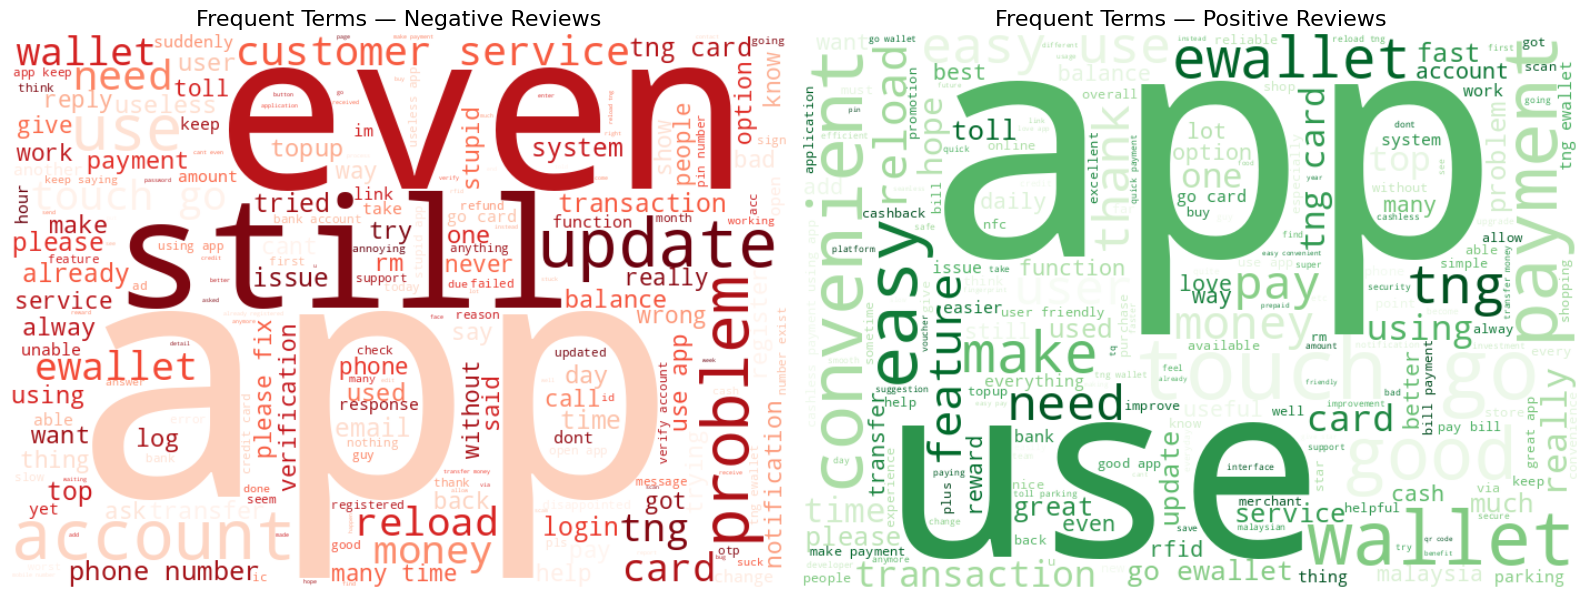

In [19]:
neg_text = ' '.join(es_df[es_df['predicted_sentiment'] == 'negative']['cleaned_text'].astype(str))
pos_text = ' '.join(es_df[es_df['predicted_sentiment'] == 'positive']['cleaned_text'].astype(str))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

wc_neg = WordCloud(width=700, height=500, background_color='white', colormap='Reds').generate(neg_text)
axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].set_title('Frequent Terms — Negative Reviews', fontsize=16)
axes[0].axis('off')

wc_pos = WordCloud(width=700, height=500, background_color='white', colormap='Greens').generate(pos_text)
axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].set_title('Frequent Terms — Positive Reviews', fontsize=16)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

In [20]:
agreement = (es_df['true_sentiment'] == es_df['predicted_sentiment']).map({True: 'Correct', False: 'Incorrect'})
agreement_counts = agreement.value_counts().reset_index()
agreement_counts.columns = ['result', 'count']

fig4 = px.bar(
    agreement_counts, x='result', y='count',
    title='Model Prediction Agreement — True vs Predicted Sentiment',
    color='result',
    color_discrete_map={'Correct': '#2ca02c', 'Incorrect': '#d62728'},
    text='count'
)
fig4.update_layout(yaxis_title='Number of Reviews', xaxis_title='')
fig4.show()

accuracy_pct = (agreement == 'Correct').mean() * 100
print(f"Overall agreement on this dataset: {accuracy_pct:.1f}%")

Overall agreement on this dataset: 73.8%


## Saving Dashboard Outputs for the Report

In [21]:
fig1.write_html('sentiment_distribution.html')
fig2.write_html('sentiment_over_time.html')
fig4.write_html('model_agreement.html')
print("Saved interactive HTML dashboards. Download these via the Colab file browser:")
print("  - sentiment_distribution.html")
print("  - sentiment_over_time.html")
print("  - model_agreement.html")
print("  - wordclouds.png")

Saved interactive HTML dashboards. Download these via the Colab file browser:
  - sentiment_distribution.html
  - sentiment_over_time.html
  - model_agreement.html
  - wordclouds.png


## Cleanup: Stop Elasticsearch

In [ ]:
!pkill -f elasticsearch
print("Elasticsearch stopped.")